# XGBoost - SOJA3 (Variacao 2: Soja Chicago + Indicadores Originais) [Out-of-Time]
## Analise comparativa de modelos de Machine Learning - Agro Brasil - TCC

Este notebook implementa modelos XGBoost para prever se o preco de fechamento das acoes SOJA3 ira subir ou nao em diferentes horizontes temporais (3, 7, 15 e 30 dias).

**Estrategia de validacao:** os ultimos 3% do dataset (dados mais recentes) sao separados como conjunto out-of-time. Nos 97% restantes, aplica-se divisao 80/20 para treino e teste.

**Dataset utilizado:** Dataset com uso de Soja Chicago em lags, mantendo as features base e os indicadores tecnicos do modelo original.

**Target:** Classificacao binaria (1 = Alta, 0 = Baixa/Estavel)

### Importacao das bibliotecas e carregamento do dataset

In [1]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

# Configuracao para salvar graficos
OUTPUT_DIR = './'
os.makedirs(OUTPUT_DIR, exist_ok=True)

COMPANY = 'SOJA3'
DATASET_LABEL = 'somente_soja_chicago_out_of_time'
DATASET_NAME = 'Somente lags de Soja Chicago (Out-of-Time)'
company_lower = COMPANY.lower()

# Carrega dataset CONSOLIDADO (SOJA3 + indicadores tecnicos + indicadores agro)
df = pd.read_csv('../../../indicadores_agro/indicador_agro_tratado/join_indicadores_de_mercado/indicadores_de_mercado_mais_indicadores_agro.csv', 
                  index_col=0, parse_dates=True)

# Forward fill para NaNs (tratamento padrao)
lag_cols = ['cambio_close_lag_1d', 'cambio_close_lag_3d', 'cambio_close_lag_6d', 'cambio_close_lag_10d',
            'soja_chicago_close_lag_1d', 'soja_chicago_close_lag_3d', 'soja_chicago_close_lag_6d', 'soja_chicago_close_lag_10d']
df[lag_cols] = df[lag_cols].fillna(method='ffill')

print('='*60)
print(f'DATASET {COMPANY} - XGBOOST ({DATASET_LABEL.upper()})')
print('='*60)
print(f'\nDataset: indicadores_de_mercado_mais_indicadores_agro.csv')
print(f'Shape: {df.shape}')
print('\nColunas disponiveis:')
print(df.columns.tolist())
print('\nPrimeiras 5 linhas:')
print(df.head())
print('\nDistribuicao das classes target:')
for col in ['target_3d', 'target_7d', 'target_15d', 'target_30d']:
    if col in df.columns:
        dist = df[col].value_counts()
        pct = df[col].mean()
        print(f'  {col}: {dist.to_dict()} (Taxa de alta: {pct:.1%})')

DATASET SOJA3 - XGBOOST (SOMENTE_SOJA_CHICAGO_OUT_OF_TIME)

Dataset: indicadores_de_mercado_mais_indicadores_agro.csv
Shape: (843, 26)

Colunas disponiveis:
['Close', 'High', 'Low', 'Open', 'Volume', 'target_3d', 'target_7d', 'target_15d', 'target_30d', 'OBV', 'FWMA', 'TEMA', 'HLC3', 'BB_upper', 'BB_middle', 'BB_lower', 'cambio_close', 'cambio_close_lag_1d', 'cambio_close_lag_3d', 'cambio_close_lag_6d', 'cambio_close_lag_10d', 'soja_chicago_close', 'soja_chicago_close_lag_1d', 'soja_chicago_close_lag_3d', 'soja_chicago_close_lag_6d', 'soja_chicago_close_lag_10d']

Primeiras 5 linhas:
                Close       High        Low       Open  Volume  target_3d  \
Date                                                                        
2021-05-27  14.380093  14.687592  14.362005  14.551931  445500          1   
2021-05-28  14.226343  14.542886  14.153991  14.425313  745100          0   
2021-06-01  14.470534  14.551931  14.027374  14.217300  594300          0   
2021-06-02  14.144947  1

### Preparacao dos dados para modelagem

In [2]:
# Definir features: base + indicadores tecnicos + lags de Soja Chicago
base_features = ['Close', 'Low', 'High', 'Open']
technical_indicators = ['OBV', 'FWMA', 'TEMA', 'HLC3', 'BB_upper', 'BB_middle', 'BB_lower']
lag_features = ['soja_chicago_close_lag_1d', 'soja_chicago_close_lag_3d', 'soja_chicago_close_lag_6d', 'soja_chicago_close_lag_10d']
all_features = base_features + technical_indicators + lag_features

X = df[all_features].copy()

# Definir targets (variaveis dependentes) - classificacao binaria
targets = {
    '3d': df['target_3d'],
    '7d': df['target_7d'],
    '15d': df['target_15d'],
    '30d': df['target_30d']
}

print('Variaveis independentes (X):')
print(X.columns.tolist())
print(f'\nShape de X: {X.shape}')
print(f'\nComposicao de features:')
print(f'  - Base features ({len(base_features)}): {base_features}')
print(f'  - Technical indicators ({len(technical_indicators)}): {technical_indicators}')
print(f'  - Lag features ({len(lag_features)}): {lag_features}')
print(f'  - Total: {len(all_features)} features')

print('\nTargets (classificacao binaria):')
for name, target in targets.items():
    print(f'  - {name}: {target.name} (1=Alta, 0=Baixa)')

Variaveis independentes (X):
['Close', 'Low', 'High', 'Open', 'OBV', 'FWMA', 'TEMA', 'HLC3', 'BB_upper', 'BB_middle', 'BB_lower', 'soja_chicago_close_lag_1d', 'soja_chicago_close_lag_3d', 'soja_chicago_close_lag_6d', 'soja_chicago_close_lag_10d']

Shape de X: (843, 15)

Composicao de features:
  - Base features (4): ['Close', 'Low', 'High', 'Open']
  - Technical indicators (7): ['OBV', 'FWMA', 'TEMA', 'HLC3', 'BB_upper', 'BB_middle', 'BB_lower']
  - Lag features (4): ['soja_chicago_close_lag_1d', 'soja_chicago_close_lag_3d', 'soja_chicago_close_lag_6d', 'soja_chicago_close_lag_10d']
  - Total: 15 features

Targets (classificacao binaria):
  - 3d: target_3d (1=Alta, 0=Baixa)
  - 7d: target_7d (1=Alta, 0=Baixa)
  - 15d: target_15d (1=Alta, 0=Baixa)
  - 30d: target_30d (1=Alta, 0=Baixa)


### Treinamento dos Modelos XGBoost (80/20 em 97% + 3% Out-of-Time)

In [3]:
print('MODELOS XGBOOST - SOJA3 (INDICADORES AGRICOLAS)')
print('='*60)

# Dicionario para armazenar modelos treinados e metricas
models = {}

xgb_params = {
    'n_estimators': 300,
    'max_depth': 4,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 1,
    'reg_lambda': 1.0,
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'random_state': 42,
    'n_jobs': -1
}

def calcular_metricas(y_true, y_pred, y_pred_proba):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    precision_alta = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
    recall_alta = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    f1_alta = f1_score(y_true, y_pred, pos_label=1, zero_division=0)

    if len(np.unique(y_true)) > 1:
        auc_roc = roc_auc_score(y_true, y_pred_proba)
    else:
        auc_roc = np.nan

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'precision_alta': precision_alta,
        'recall_alta': recall_alta,
        'f1_alta': f1_alta,
        'auc_roc': auc_roc
    }

for period, y in targets.items():
    # Remover linhas com NaN e preservar ordem temporal para definir OOT
    mask = ~(X.isnull().any(axis=1) | y.isnull())
    X_clean = X.loc[mask].copy()
    y_clean = y.loc[mask].copy()

    n_total = len(X_clean)
    n_oot = max(1, int(np.ceil(n_total * 0.03)))
    n_dev = n_total - n_oot

    X_dev = X_clean.iloc[:n_dev]
    y_dev = y_clean.iloc[:n_dev]
    X_oot = X_clean.iloc[n_dev:]
    y_oot = y_clean.iloc[n_dev:]

    # 80/20 em cima dos 97% com embaralhamento (igual ao script base)
    X_train, X_test, y_train, y_test = train_test_split(
        X_dev, y_dev, test_size=0.2, random_state=42, stratify=y_dev, shuffle=True
    )

    # Treinar
    model = XGBClassifier(**xgb_params)
    model.fit(X_train, y_train)

    # Predicoes no teste (20% embaralhado dentro dos 97%)
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    metricas_teste = calcular_metricas(y_test, y_pred, y_pred_proba)

    # Predicoes no out-of-time (ultimos 3%)
    y_pred_oot = model.predict(X_oot)
    y_pred_proba_oot = model.predict_proba(X_oot)[:, 1]
    metricas_oot = calcular_metricas(y_oot, y_pred_oot, y_pred_proba_oot)

    models[period] = {
        'model': model,
        'X_train': X_train,
        'X_test': X_test,
        'X_oot': X_oot,
        'y_train': y_train,
        'y_test': y_test,
        'y_oot': y_oot,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba,
        'y_pred_oot': y_pred_oot,
        'y_pred_proba_oot': y_pred_proba_oot,
        'split_info': {
            'n_total': n_total,
            'n_dev': n_dev,
            'n_oot': n_oot
        },
        **metricas_teste,
        'accuracy_oot': metricas_oot['accuracy'],
        'precision_oot': metricas_oot['precision'],
        'recall_oot': metricas_oot['recall'],
        'f1_oot': metricas_oot['f1'],
        'precision_alta_oot': metricas_oot['precision_alta'],
        'recall_alta_oot': metricas_oot['recall_alta'],
        'f1_alta_oot': metricas_oot['f1_alta'],
        'auc_roc_oot': metricas_oot['auc_roc']
    }

    print(f'\nMODELO {period.upper()} - Classificacao {period} futuro:')
    print(f"  Split temporal: Total={n_total} | Desenvolvimento (97%)={n_dev} | Out-of-time (3%)={n_oot}")
    print('  [Teste 20% embaralhado dentro dos 97%]')
    print(f"  Accuracy: {metricas_teste['accuracy']:.4f}")
    print(f"  Precision (weighted): {metricas_teste['precision']:.4f}")
    print(f"  Recall (weighted): {metricas_teste['recall']:.4f}")
    print(f"  F1-Score (weighted): {metricas_teste['f1']:.4f}")
    print(f"  AUC-ROC: {metricas_teste['auc_roc']:.4f}")
    print('  --- Classe Alta (Teste) ---')
    print(f"  Precision (Alta): {metricas_teste['precision_alta']:.4f}")
    print(f"  Recall (Alta): {metricas_teste['recall_alta']:.4f}")
    print(f"  F1-Score (Alta): {metricas_teste['f1_alta']:.4f}")
    print('  [Out-of-Time: ultimos 3%]')
    print(f"  Accuracy OOT: {metricas_oot['accuracy']:.4f}")
    print(f"  Precision OOT (weighted): {metricas_oot['precision']:.4f}")
    print(f"  Recall OOT (weighted): {metricas_oot['recall']:.4f}")
    print(f"  F1-Score OOT (weighted): {metricas_oot['f1']:.4f}")
    print(f"  AUC-ROC OOT: {metricas_oot['auc_roc']:.4f}")

print('\n' + '='*60)
print('OK - 4 modelos treinados com validacao temporal e avaliacao out-of-time!')
print('='*60)

MODELOS XGBOOST - SOJA3 (INDICADORES AGRICOLAS)

MODELO 3D - Classificacao 3d futuro:
  Split temporal: Total=843 | Desenvolvimento (97%)=817 | Out-of-time (3%)=26
  [Teste 20% embaralhado dentro dos 97%]
  Accuracy: 0.7317
  Precision (weighted): 0.7317
  Recall (weighted): 0.7317
  F1-Score (weighted): 0.7317
  AUC-ROC: 0.7934
  --- Classe Alta (Teste) ---
  Precision (Alta): 0.7215
  Recall (Alta): 0.7215
  F1-Score (Alta): 0.7215
  [Out-of-Time: ultimos 3%]
  Accuracy OOT: 0.5000
  Precision OOT (weighted): 0.5000
  Recall OOT (weighted): 0.5000
  F1-Score OOT (weighted): 0.4933
  AUC-ROC OOT: 0.5148

MODELO 7D - Classificacao 7d futuro:
  Split temporal: Total=843 | Desenvolvimento (97%)=817 | Out-of-time (3%)=26
  [Teste 20% embaralhado dentro dos 97%]
  Accuracy: 0.7683
  Precision (weighted): 0.7738
  Recall (weighted): 0.7683
  F1-Score (weighted): 0.7668
  AUC-ROC: 0.8435
  --- Classe Alta (Teste) ---
  Precision (Alta): 0.8116
  Recall (Alta): 0.6914
  F1-Score (Alta): 0.746

### Tabela Resumo das Metricas

In [4]:
# Criar DataFrame com resumo das metricas (Teste e Out-of-Time)
metrics_summary = pd.DataFrame({
    'Horizonte': ['3 dias', '7 dias', '15 dias', '30 dias'],
    'Accuracy_Teste': [models['3d']['accuracy'], models['7d']['accuracy'], models['15d']['accuracy'], models['30d']['accuracy']],
    'F1_Teste': [models['3d']['f1'], models['7d']['f1'], models['15d']['f1'], models['30d']['f1']],
    'AUC_Teste': [models['3d']['auc_roc'], models['7d']['auc_roc'], models['15d']['auc_roc'], models['30d']['auc_roc']],
    'Accuracy_OOT': [models['3d']['accuracy_oot'], models['7d']['accuracy_oot'], models['15d']['accuracy_oot'], models['30d']['accuracy_oot']],
    'F1_OOT': [models['3d']['f1_oot'], models['7d']['f1_oot'], models['15d']['f1_oot'], models['30d']['f1_oot']],
    'AUC_OOT': [models['3d']['auc_roc_oot'], models['7d']['auc_roc_oot'], models['15d']['auc_roc_oot'], models['30d']['auc_roc_oot']]
})

print('\nRESUMO DAS METRICAS - SOJA3 (OUT-OF-TIME)')
print('='*80)
print(metrics_summary.to_string(index=False))

# Salvar metricas em CSV
metrics_summary.to_csv(f'{OUTPUT_DIR}metricas_{company_lower}_{DATASET_LABEL}.csv', index=False)
print(f'\nOK - Metricas salvas em metricas_{company_lower}_{DATASET_LABEL}.csv')


RESUMO DAS METRICAS - SOJA3 (OUT-OF-TIME)
Horizonte  Accuracy_Teste  F1_Teste  AUC_Teste  Accuracy_OOT   F1_OOT  AUC_OOT
   3 dias        0.731707  0.731707   0.793448      0.500000 0.493253 0.514793
   7 dias        0.768293  0.766835   0.843522      0.615385 0.561966 0.571429
  15 dias        0.865854  0.865774   0.919434      0.807692 0.806268 0.915152
  30 dias        0.847561  0.847635   0.955356      0.769231 0.869565      NaN

OK - Metricas salvas em metricas_soja3_somente_soja_chicago_out_of_time.csv


---
# Analises Graficas

### Matrizes de Confusao

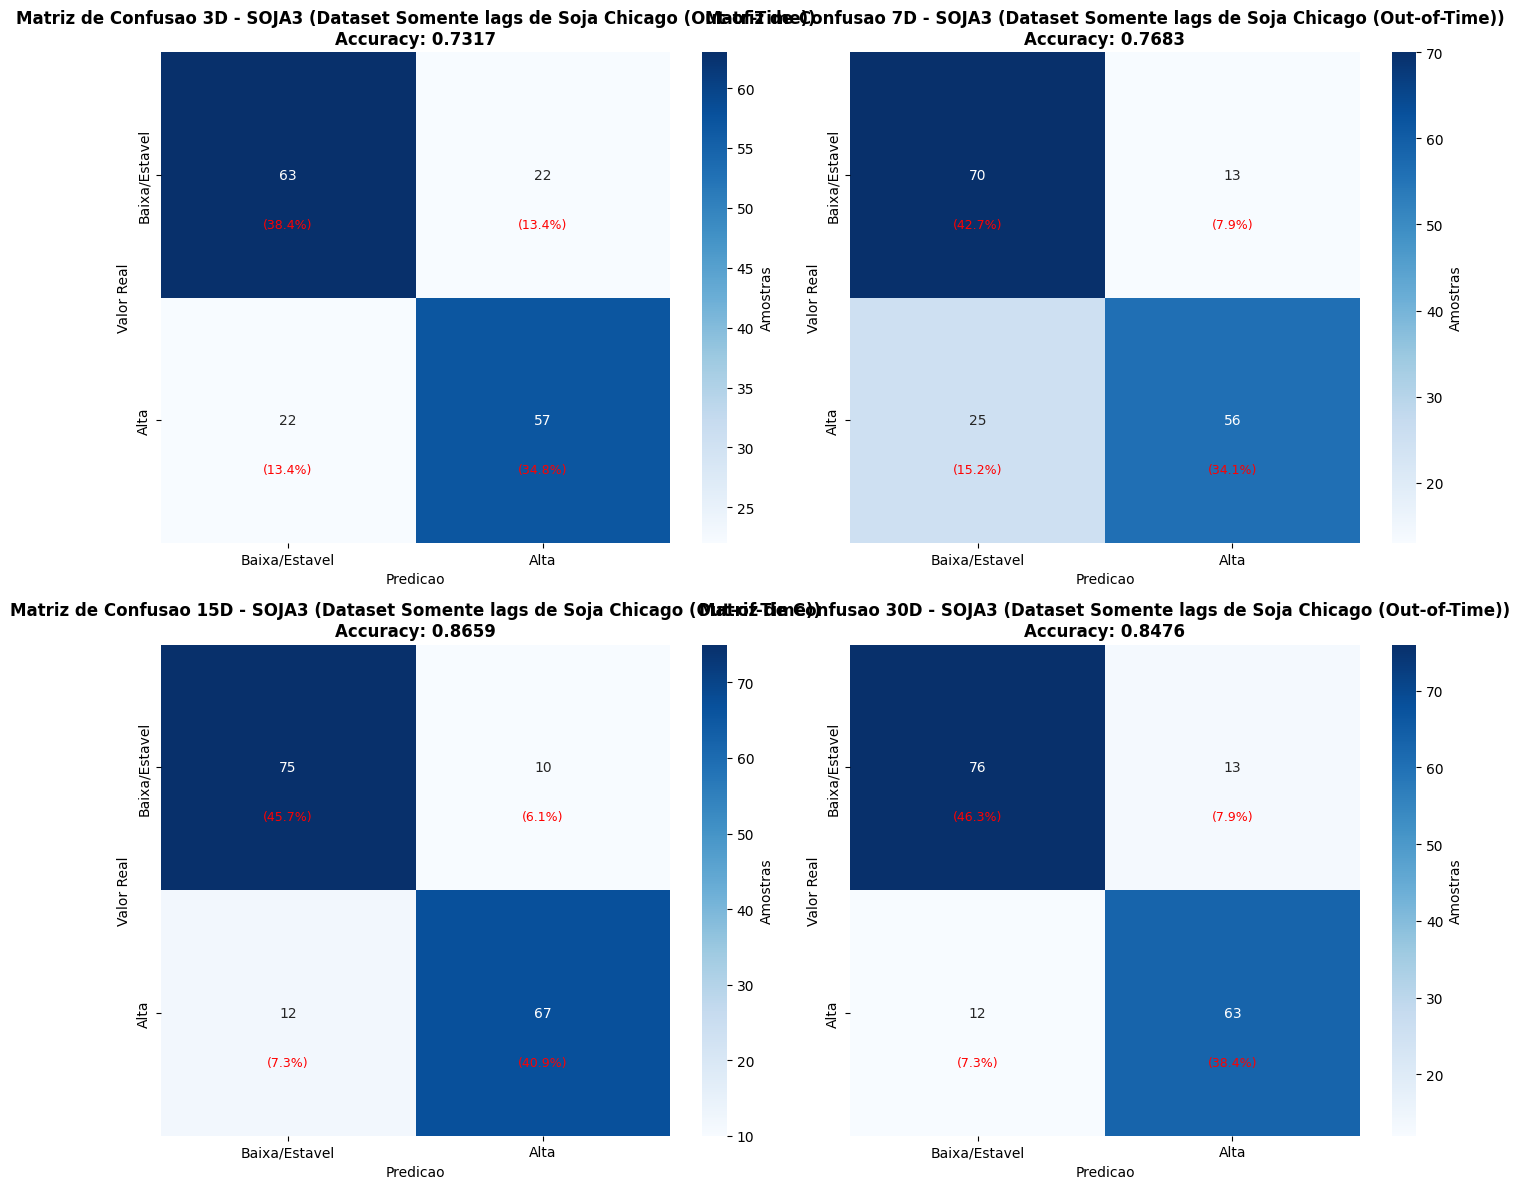

OK - Matrizes de confusao salvas


In [5]:
# Matrizes de Confusao
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, (period, model_data) in enumerate(models.items()):
    y_test = model_data['y_test']
    y_pred = model_data['y_pred']

    cm = confusion_matrix(y_test, y_pred)

    ax = axes[idx]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Baixa/Estavel', 'Alta'],
                yticklabels=['Baixa/Estavel', 'Alta'],
                cbar_kws={'label': 'Amostras'})

    ax.set_title(f'Matriz de Confusao {period.upper()} - {COMPANY} (Dataset {DATASET_NAME})\nAccuracy: {model_data["accuracy"]:.4f}', fontweight='bold')
    ax.set_xlabel('Predicao')
    ax.set_ylabel('Valor Real')

    # Adicionar porcentagens
    total = cm.sum()
    for i in range(2):
        for j in range(2):
            pct = (cm[i, j] / total) * 100
            ax.text(j + 0.5, i + 0.7, f'({pct:.1f}%)', ha='center', va='center', fontsize=9, color='red')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}matriz_confusao_{company_lower}_{DATASET_LABEL}.png', dpi=300, bbox_inches='tight')
plt.show()
print('OK - Matrizes de confusao salvas')

### Curvas ROC

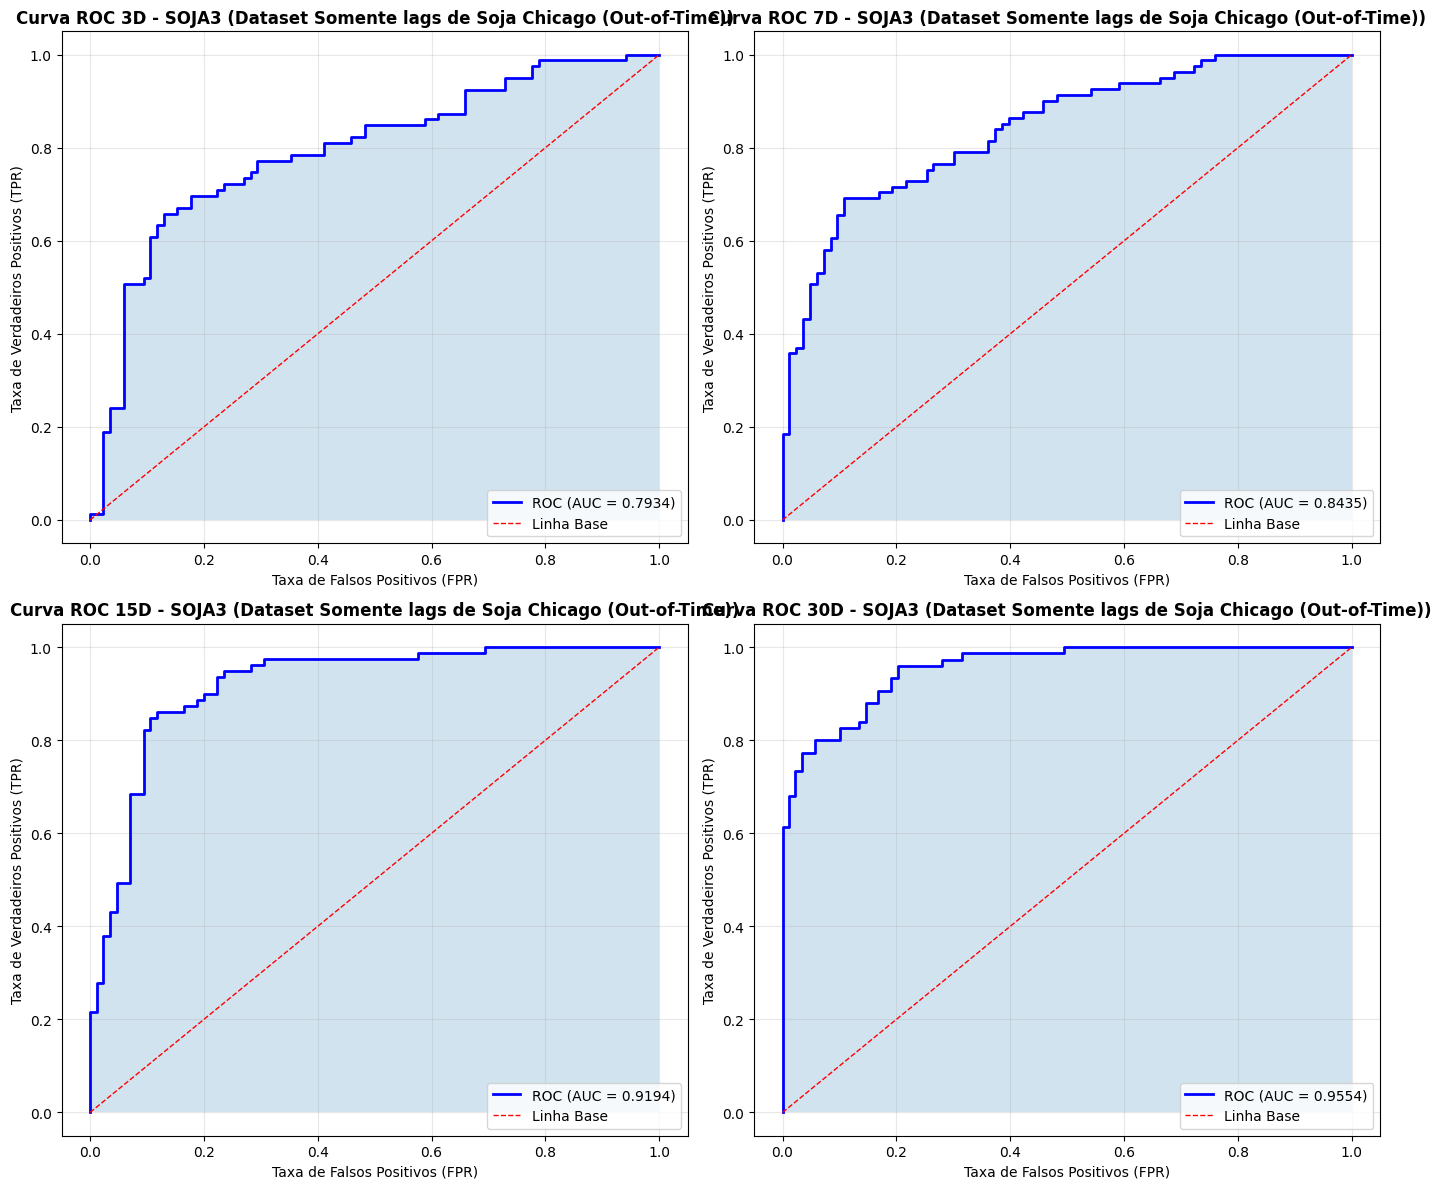

OK - Curvas ROC salvas


In [6]:
# Curvas ROC
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, (period, model_data) in enumerate(models.items()):
    y_test = model_data['y_test']
    y_pred_proba = model_data['y_pred_proba']
    auc = model_data['auc_roc']

    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

    ax = axes[idx]
    ax.plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC (AUC = {auc:.4f})')
    ax.plot([0, 1], [0, 1], 'r--', linewidth=1, label='Linha Base')
    ax.fill_between(fpr, tpr, alpha=0.2)

    ax.set_title(f'Curva ROC {period.upper()} - {COMPANY} (Dataset {DATASET_NAME})', fontweight='bold')
    ax.set_xlabel('Taxa de Falsos Positivos (FPR)')
    ax.set_ylabel('Taxa de Verdadeiros Positivos (TPR)')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}curva_roc_{company_lower}_{DATASET_LABEL}.png', dpi=300, bbox_inches='tight')
plt.show()
print('OK - Curvas ROC salvas')

### Avaliacao Out-of-Time (Ultimos 3%)

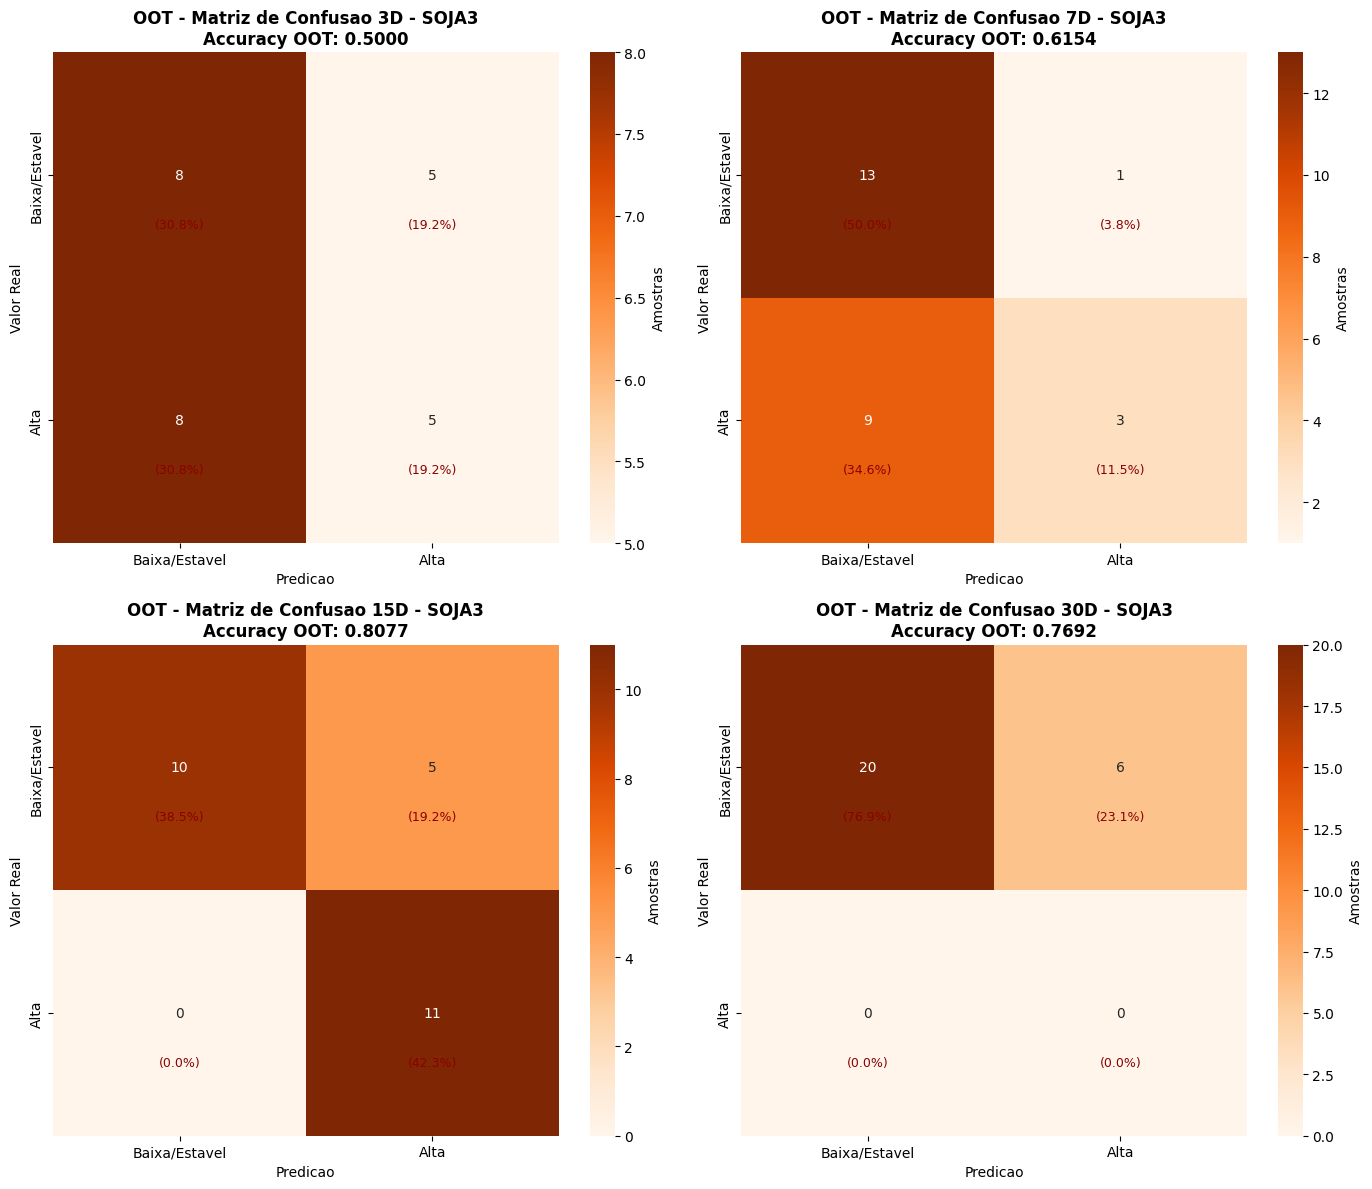

OK - Matrizes de confusao Out-of-Time salvas


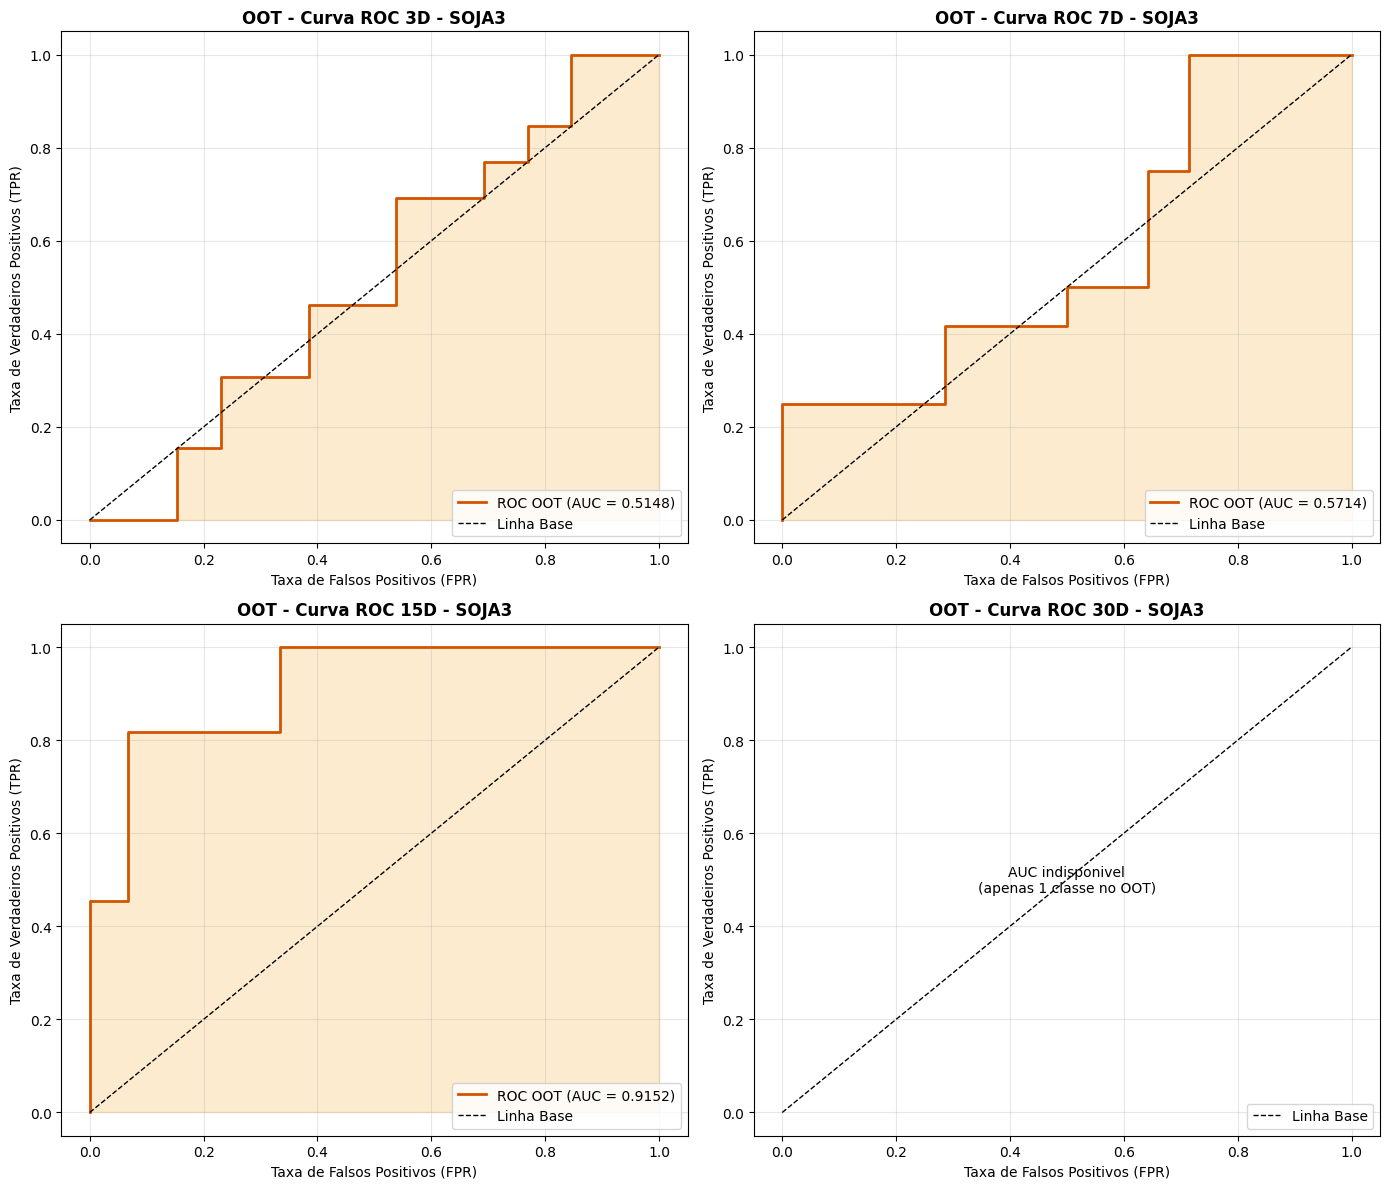

OK - Curvas ROC Out-of-Time salvas


In [7]:
# Matrizes de confusao Out-of-Time
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, (period, model_data) in enumerate(models.items()):
    y_oot = model_data['y_oot']
    y_pred_oot = model_data['y_pred_oot']

    cm = confusion_matrix(y_oot, y_pred_oot)

    ax = axes[idx]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=ax,
                xticklabels=['Baixa/Estavel', 'Alta'],
                yticklabels=['Baixa/Estavel', 'Alta'],
                cbar_kws={'label': 'Amostras'})

    ax.set_title(
        f'OOT - Matriz de Confusao {period.upper()} - {COMPANY}\nAccuracy OOT: {model_data["accuracy_oot"]:.4f}',
        fontweight='bold'
    )
    ax.set_xlabel('Predicao')
    ax.set_ylabel('Valor Real')

    total = cm.sum()
    for i in range(2):
        for j in range(2):
            pct = (cm[i, j] / total) * 100 if total > 0 else 0
            ax.text(j + 0.5, i + 0.7, f'({pct:.1f}%)', ha='center', va='center', fontsize=9, color='darkred')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}oot_matriz_confusao_{company_lower}_{DATASET_LABEL}.png', dpi=300, bbox_inches='tight')
plt.show()
print('OK - Matrizes de confusao Out-of-Time salvas')

# Curvas ROC Out-of-Time
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, (period, model_data) in enumerate(models.items()):
    y_oot = model_data['y_oot']
    y_pred_proba_oot = model_data['y_pred_proba_oot']
    auc_oot = model_data['auc_roc_oot']

    ax = axes[idx]
    if len(np.unique(y_oot)) > 1:
        fpr, tpr, _ = roc_curve(y_oot, y_pred_proba_oot)
        ax.plot(fpr, tpr, color='#d35400', linewidth=2, label=f'ROC OOT (AUC = {auc_oot:.4f})')
        ax.fill_between(fpr, tpr, alpha=0.2, color='#f39c12')
    else:
        ax.text(0.5, 0.5, 'AUC indisponivel\n(apenas 1 classe no OOT)', ha='center', va='center')

    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Linha Base')
    ax.set_title(f'OOT - Curva ROC {period.upper()} - {COMPANY}', fontweight='bold')
    ax.set_xlabel('Taxa de Falsos Positivos (FPR)')
    ax.set_ylabel('Taxa de Verdadeiros Positivos (TPR)')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}oot_curva_roc_{company_lower}_{DATASET_LABEL}.png', dpi=300, bbox_inches='tight')
plt.show()
print('OK - Curvas ROC Out-of-Time salvas')

### Comparacao Teste vs Out-of-Time

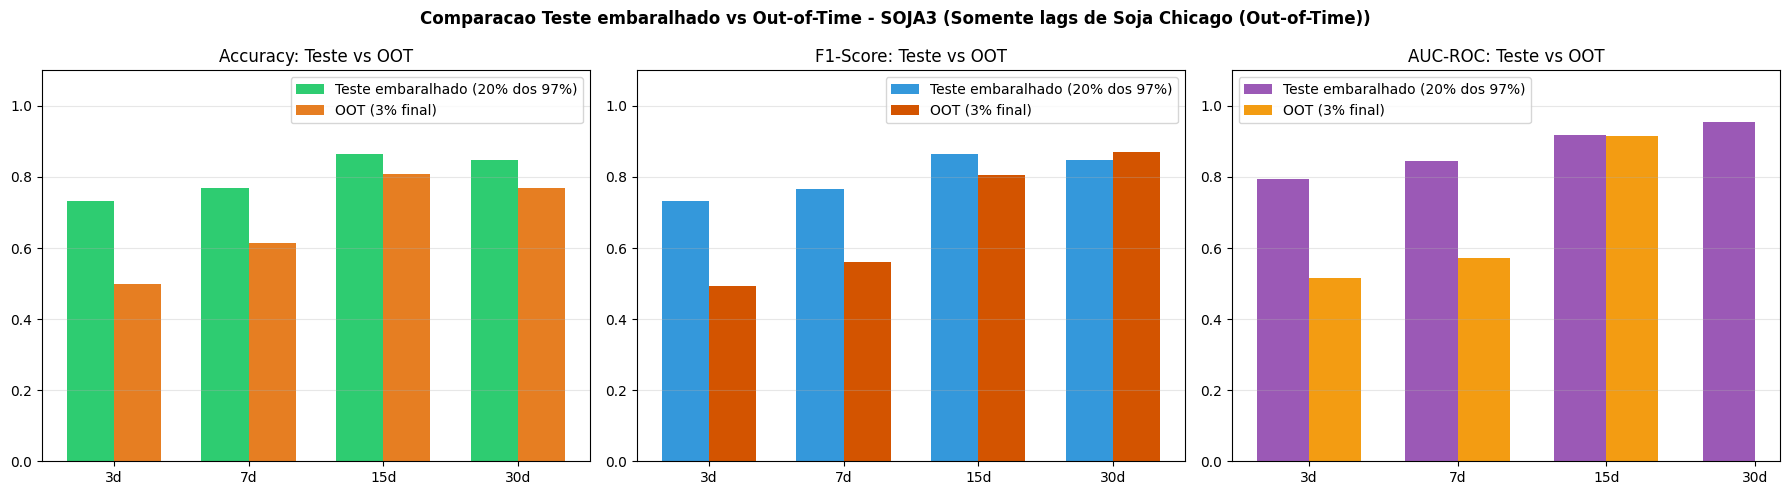

OK - Grafico de comparacao Teste embaralhado vs Out-of-Time salvo


In [8]:
# Comparacao entre metricas de teste embaralhado e out-of-time
periods = ['3d', '7d', '15d', '30d']
x = np.arange(len(periods))
width = 0.35

acc_test = [models[p]['accuracy'] for p in periods]
acc_oot = [models[p]['accuracy_oot'] for p in periods]
f1_test = [models[p]['f1'] for p in periods]
f1_oot = [models[p]['f1_oot'] for p in periods]
auc_test = [models[p]['auc_roc'] for p in periods]
auc_oot = [models[p]['auc_roc_oot'] for p in periods]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(x - width/2, acc_test, width, label='Teste embaralhado (20% dos 97%)', color='#2ecc71')
axes[0].bar(x + width/2, acc_oot, width, label='OOT (3% final)', color='#e67e22')
axes[0].set_title('Accuracy: Teste vs OOT')
axes[0].set_xticks(x)
axes[0].set_xticklabels(periods)
axes[0].set_ylim(0, 1.1)
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].legend()

axes[1].bar(x - width/2, f1_test, width, label='Teste embaralhado (20% dos 97%)', color='#3498db')
axes[1].bar(x + width/2, f1_oot, width, label='OOT (3% final)', color='#d35400')
axes[1].set_title('F1-Score: Teste vs OOT')
axes[1].set_xticks(x)
axes[1].set_xticklabels(periods)
axes[1].set_ylim(0, 1.1)
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].legend()

axes[2].bar(x - width/2, auc_test, width, label='Teste embaralhado (20% dos 97%)', color='#9b59b6')
axes[2].bar(x + width/2, auc_oot, width, label='OOT (3% final)', color='#f39c12')
axes[2].set_title('AUC-ROC: Teste vs OOT')
axes[2].set_xticks(x)
axes[2].set_xticklabels(periods)
axes[2].set_ylim(0, 1.1)
axes[2].grid(True, alpha=0.3, axis='y')
axes[2].legend()

plt.suptitle(f'Comparacao Teste embaralhado vs Out-of-Time - {COMPANY} ({DATASET_NAME})', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}comparacao_teste_vs_oot_{company_lower}_{DATASET_LABEL}.png', dpi=300, bbox_inches='tight')
plt.show()
print('OK - Grafico de comparacao Teste embaralhado vs Out-of-Time salvo')

### Comparacao das Metricas por Horizonte

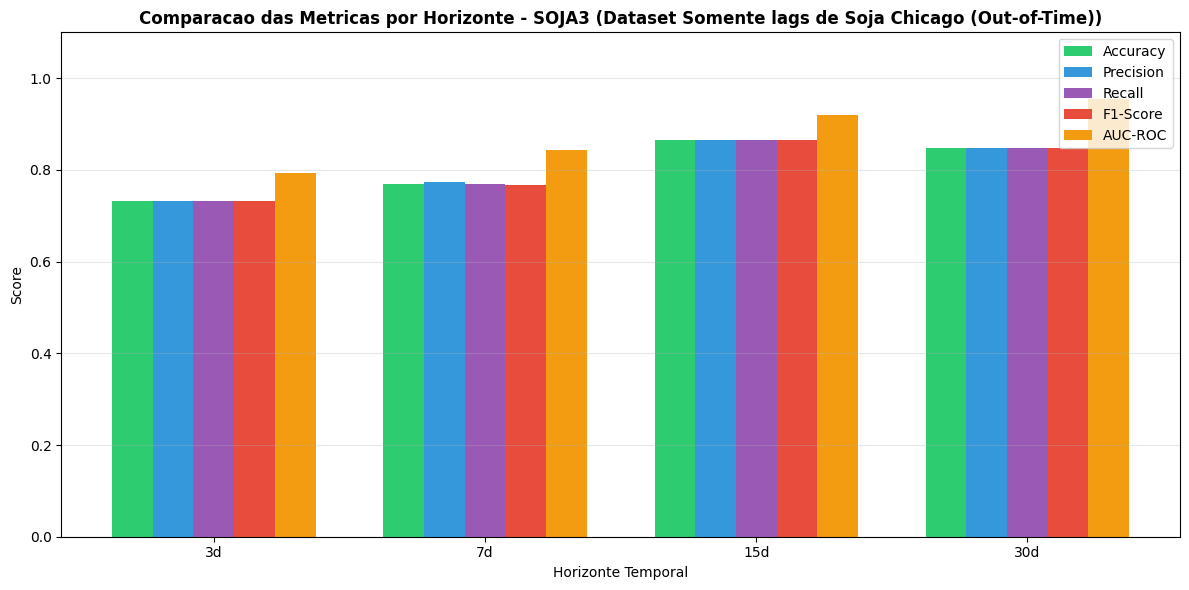

OK - Grafico de comparacao de metricas salvo


In [9]:
# Comparacao das metricas
periods = ['3d', '7d', '15d', '30d']
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']

accuracy_vals = [models[p]['accuracy'] for p in periods]
precision_vals = [models[p]['precision'] for p in periods]
recall_vals = [models[p]['recall'] for p in periods]
f1_vals = [models[p]['f1'] for p in periods]
auc_vals = [models[p]['auc_roc'] for p in periods]

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(periods))
width = 0.15

bars1 = ax.bar(x - 2 * width, accuracy_vals, width, label='Accuracy', color='#2ecc71')
bars2 = ax.bar(x - width, precision_vals, width, label='Precision', color='#3498db')
bars3 = ax.bar(x, recall_vals, width, label='Recall', color='#9b59b6')
bars4 = ax.bar(x + width, f1_vals, width, label='F1-Score', color='#e74c3c')
bars5 = ax.bar(x + 2 * width, auc_vals, width, label='AUC-ROC', color='#f39c12')

ax.set_xlabel('Horizonte Temporal')
ax.set_ylabel('Score')
ax.set_title(f'Comparacao das Metricas por Horizonte - {COMPANY} (Dataset {DATASET_NAME})', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(periods)
ax.legend(loc='upper right')
ax.set_ylim(0, 1.1)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}comparacao_metricas_{company_lower}_{DATASET_LABEL}.png', dpi=300, bbox_inches='tight')
plt.show()
print('OK - Grafico de comparacao de metricas salvo')

### Evolucao das Metricas por Horizonte

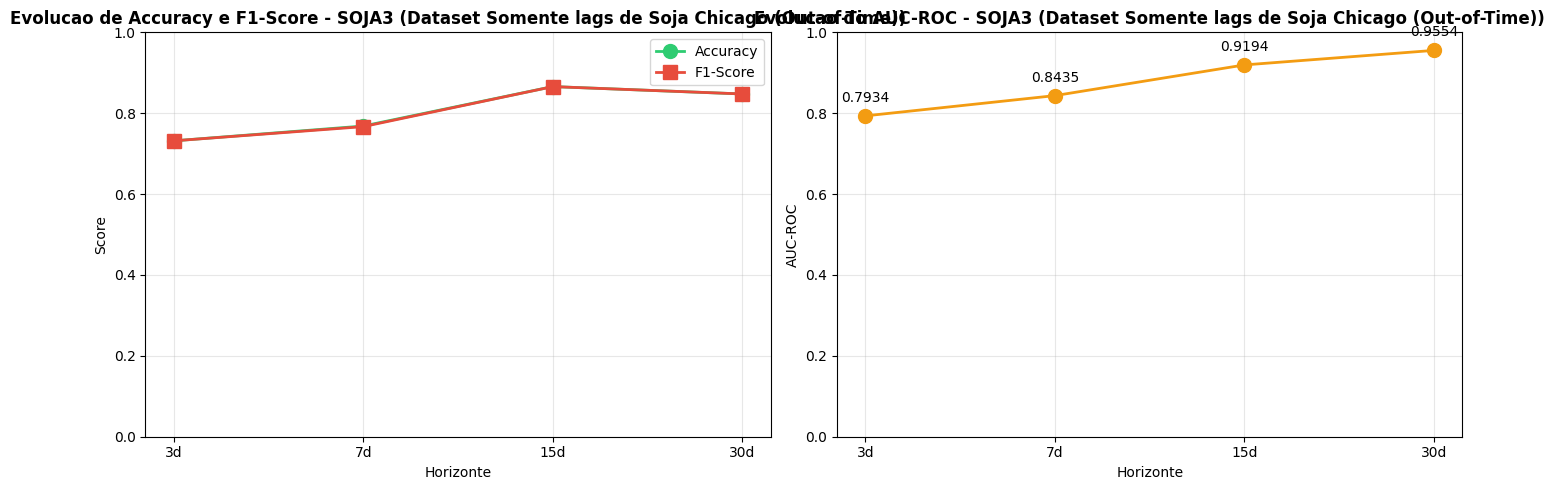

OK - Graficos de evolucao salvos


In [10]:
# Evolucao das metricas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Accuracy e F1-Score
axes[0].plot(periods, accuracy_vals, marker='o', linewidth=2, markersize=10, label='Accuracy', color='#2ecc71')
axes[0].plot(periods, f1_vals, marker='s', linewidth=2, markersize=10, label='F1-Score', color='#e74c3c')
axes[0].set_title(f'Evolucao de Accuracy e F1-Score - {COMPANY} (Dataset {DATASET_NAME})', fontweight='bold')
axes[0].set_xlabel('Horizonte')
axes[0].set_ylabel('Score')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 1)

# Plot AUC-ROC
axes[1].plot(periods, auc_vals, marker='o', linewidth=2, markersize=10, color='#f39c12')
axes[1].set_title(f'Evolucao do AUC-ROC - {COMPANY} (Dataset {DATASET_NAME})', fontweight='bold')
axes[1].set_xlabel('Horizonte')
axes[1].set_ylabel('AUC-ROC')
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 1)

for i, v in enumerate(auc_vals):
    axes[1].annotate(f'{v:.4f}', (periods[i], v), textcoords='offset points', xytext=(0, 10), ha='center')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}evolucao_metricas_{company_lower}_{DATASET_LABEL}.png', dpi=300, bbox_inches='tight')
plt.show()
print('OK - Graficos de evolucao salvos')

### Metricas da Classe Alta (Positiva)

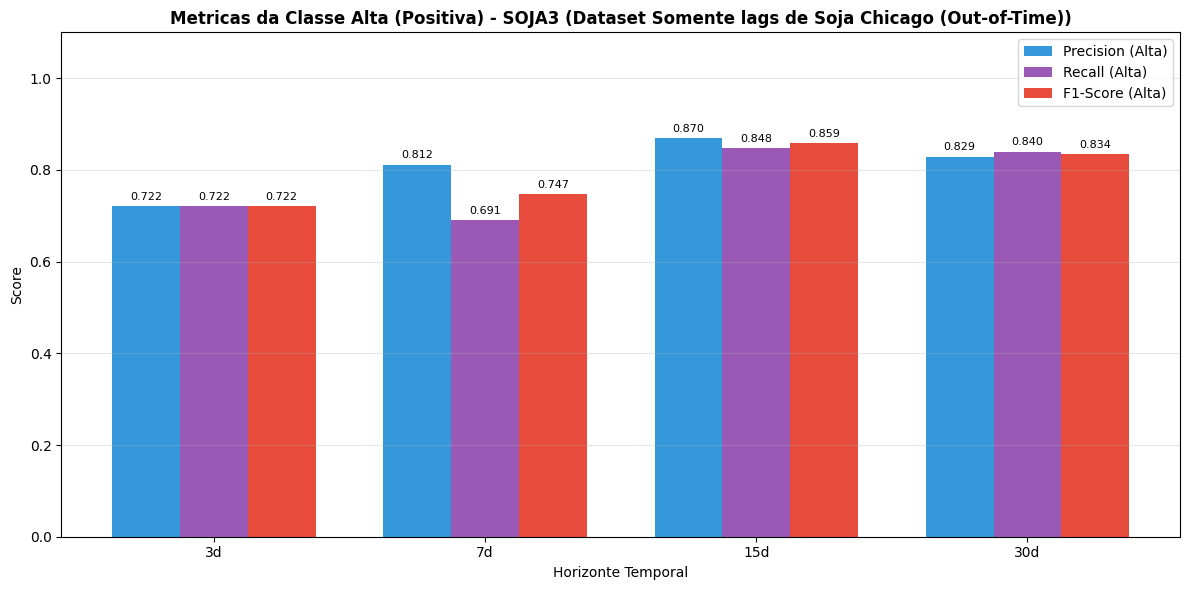

OK - Metricas da classe Alta salvas


In [11]:
# Metricas especificas da classe Alta
precision_alta_vals = [models[p]['precision_alta'] for p in periods]
recall_alta_vals = [models[p]['recall_alta'] for p in periods]
f1_alta_vals = [models[p]['f1_alta'] for p in periods]

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(periods))
width = 0.25

bars1 = ax.bar(x - width, precision_alta_vals, width, label='Precision (Alta)', color='#3498db')
bars2 = ax.bar(x, recall_alta_vals, width, label='Recall (Alta)', color='#9b59b6')
bars3 = ax.bar(x + width, f1_alta_vals, width, label='F1-Score (Alta)', color='#e74c3c')

ax.set_xlabel('Horizonte Temporal')
ax.set_ylabel('Score')
ax.set_title(f'Metricas da Classe Alta (Positiva) - {COMPANY} (Dataset {DATASET_NAME})', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(periods)
ax.legend()
ax.set_ylim(0, 1.1)
ax.grid(True, alpha=0.3, axis='y')

# Adicionar valores nas barras
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords='offset points', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}metricas_classe_alta_{company_lower}_{DATASET_LABEL}.png', dpi=300, bbox_inches='tight')
plt.show()
print('OK - Metricas da classe Alta salvas')

### Relatorio de Classificacao Detalhado

In [12]:
# Relatorio de classificacao detalhado
print('\n' + '='*70)
print(f'RELATORIO DE CLASSIFICACAO DETALHADO - {COMPANY} (DATASET {DATASET_LABEL.upper()})')
print('='*70)

for period, model_data in models.items():
    print('\n' + '-' * 60)
    print(f'HORIZONTE: {period.upper()}')
    print('-' * 60)
    print('[Teste 20% embaralhado dentro dos 97%]')
    print(classification_report(model_data['y_test'], model_data['y_pred'],
                                target_names=['Baixa/Estavel', 'Alta']))
    print('[Out-of-Time: ultimos 3%]')
    print(classification_report(model_data['y_oot'], model_data['y_pred_oot'],
                                target_names=['Baixa/Estavel', 'Alta']))


RELATORIO DE CLASSIFICACAO DETALHADO - SOJA3 (DATASET SOMENTE_SOJA_CHICAGO_OUT_OF_TIME)

------------------------------------------------------------
HORIZONTE: 3D
------------------------------------------------------------
[Teste 20% embaralhado dentro dos 97%]
               precision    recall  f1-score   support

Baixa/Estavel       0.74      0.74      0.74        85
         Alta       0.72      0.72      0.72        79

     accuracy                           0.73       164
    macro avg       0.73      0.73      0.73       164
 weighted avg       0.73      0.73      0.73       164

[Out-of-Time: ultimos 3%]
               precision    recall  f1-score   support

Baixa/Estavel       0.50      0.62      0.55        13
         Alta       0.50      0.38      0.43        13

     accuracy                           0.50        26
    macro avg       0.50      0.50      0.49        26
 weighted avg       0.50      0.50      0.49        26


------------------------------------------

### Resumo Final

In [13]:
print('\n' + '='*70)
print(f'RESUMO FINAL - XGBOOST {COMPANY} (DATASET {DATASET_LABEL.upper()})')
print('='*70)
print('\nOK - 4 modelos treinados (horizontes: 3d, 7d, 15d, 30d)')
print('OK - Estrategia temporal aplicada: ultimos 3% reservados para out-of-time')
print('OK - Teste interno com 20% embaralhado dos 97% (igual ao script base)')
print(f'OK - Features base: {base_features}')
print(f'OK - Features lag: {lag_features}')
print(f'OK - Total de features: {len(all_features)}')

print('\nMetricas por horizonte (Teste 20% embaralhado vs Out-of-Time 3%):')
periods = ['3d', '7d', '15d', '30d']
for period in periods:
    m = models[period]
    print(
        f"  {period}: "
        f"Teste[Acc={m['accuracy']:.4f}, F1={m['f1']:.4f}, AUC={m['auc_roc']:.4f}] | "
        f"OOT[Acc={m['accuracy_oot']:.4f}, F1={m['f1_oot']:.4f}, AUC={m['auc_roc_oot']:.4f}]"
    )

print('\nArquivos gerados:')
print(f'  - metricas_{company_lower}_{DATASET_LABEL}.csv')
print(f'  - matriz_confusao_{company_lower}_{DATASET_LABEL}.png')
print(f'  - curva_roc_{company_lower}_{DATASET_LABEL}.png')
print(f'  - comparacao_metricas_{company_lower}_{DATASET_LABEL}.png')
print(f'  - evolucao_metricas_{company_lower}_{DATASET_LABEL}.png')
print(f'  - metricas_classe_alta_{company_lower}_{DATASET_LABEL}.png')
print(f'  - oot_matriz_confusao_{company_lower}_{DATASET_LABEL}.png')
print(f'  - oot_curva_roc_{company_lower}_{DATASET_LABEL}.png')
print(f'  - comparacao_teste_vs_oot_{company_lower}_{DATASET_LABEL}.png')
print('='*70)


RESUMO FINAL - XGBOOST SOJA3 (DATASET SOMENTE_SOJA_CHICAGO_OUT_OF_TIME)

OK - 4 modelos treinados (horizontes: 3d, 7d, 15d, 30d)
OK - Estrategia temporal aplicada: ultimos 3% reservados para out-of-time
OK - Teste interno com 20% embaralhado dos 97% (igual ao script base)
OK - Features base: ['Close', 'Low', 'High', 'Open']
OK - Features lag: ['soja_chicago_close_lag_1d', 'soja_chicago_close_lag_3d', 'soja_chicago_close_lag_6d', 'soja_chicago_close_lag_10d']
OK - Total de features: 15

Metricas por horizonte (Teste 20% embaralhado vs Out-of-Time 3%):
  3d: Teste[Acc=0.7317, F1=0.7317, AUC=0.7934] | OOT[Acc=0.5000, F1=0.4933, AUC=0.5148]
  7d: Teste[Acc=0.7683, F1=0.7668, AUC=0.8435] | OOT[Acc=0.6154, F1=0.5620, AUC=0.5714]
  15d: Teste[Acc=0.8659, F1=0.8658, AUC=0.9194] | OOT[Acc=0.8077, F1=0.8063, AUC=0.9152]
  30d: Teste[Acc=0.8476, F1=0.8476, AUC=0.9554] | OOT[Acc=0.7692, F1=0.8696, AUC=nan]

Arquivos gerados:
  - metricas_soja3_somente_soja_chicago_out_of_time.csv
  - matriz_confu

## Importancia das Variaveis por Horizonte (Top 10)

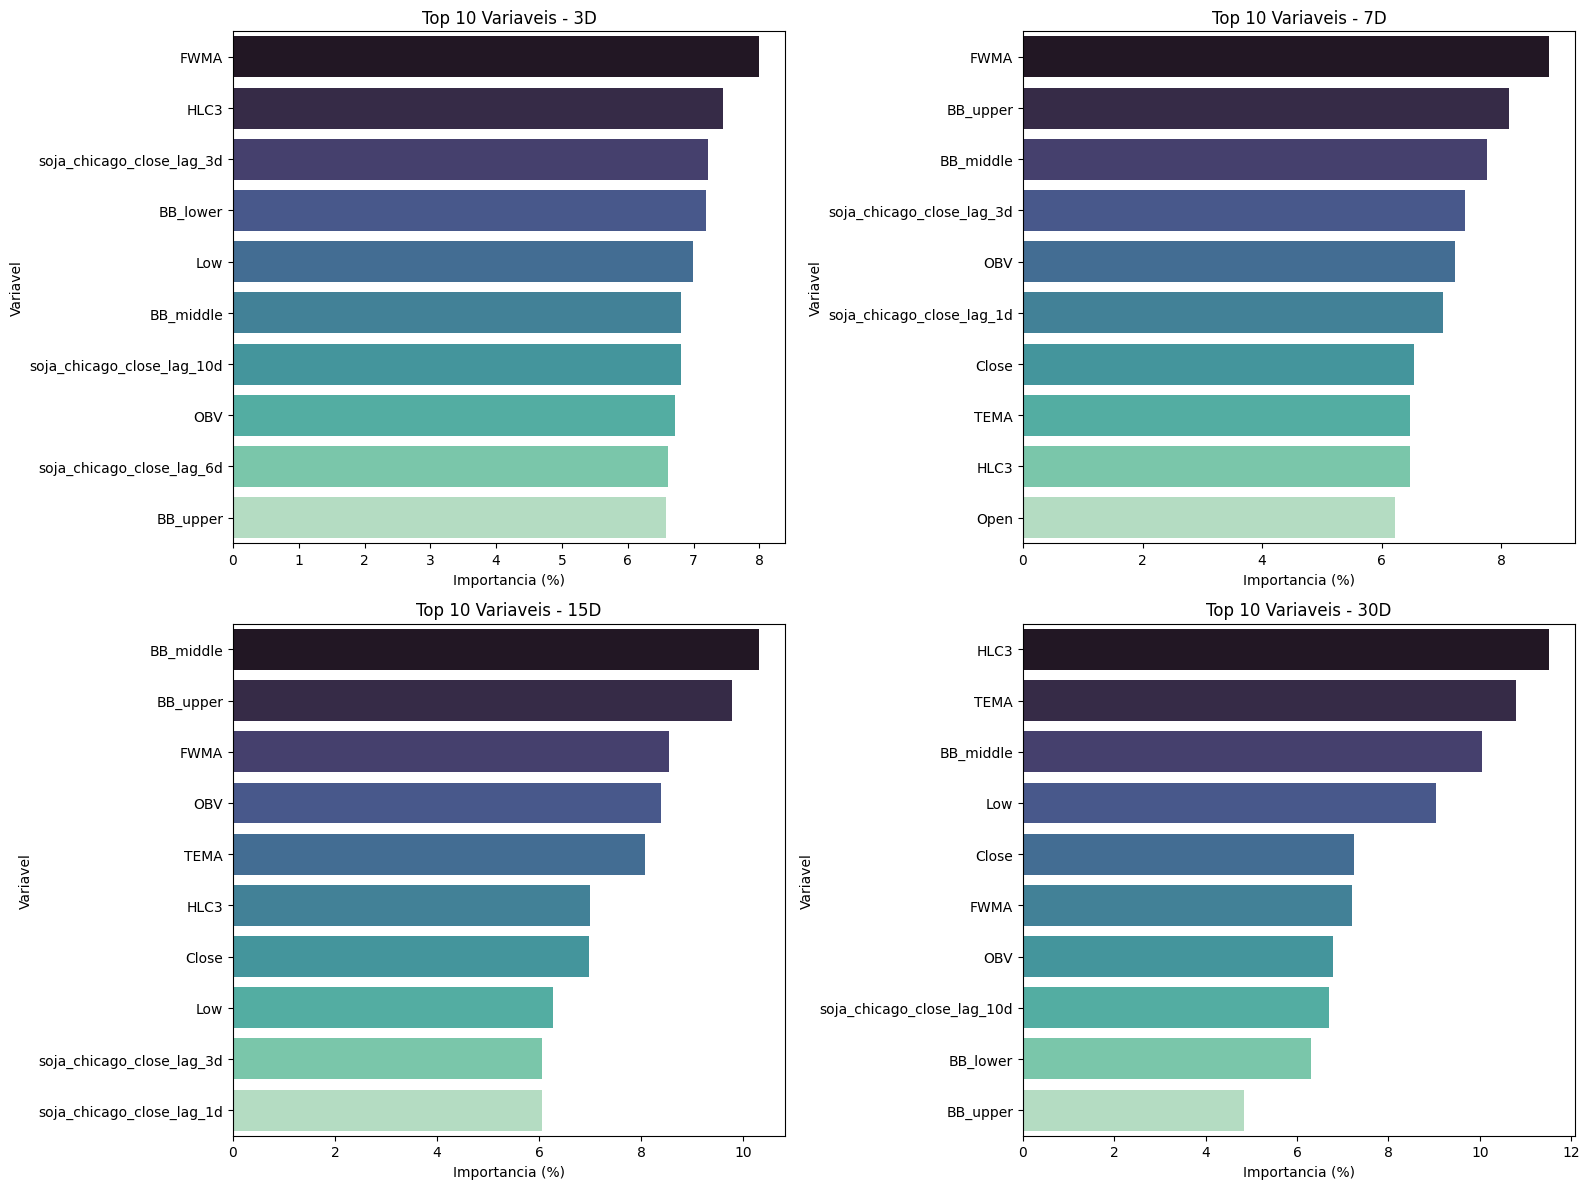

Resumo dos maiores pesos por horizonte:

HORIZONTE 3D - TOP 10
                  Variavel  Peso (%)
                      FWMA  7.988667
                      HLC3  7.442460
 soja_chicago_close_lag_3d  7.218541
                  BB_lower  7.180873
                       Low  6.989136
                 BB_middle  6.812742
soja_chicago_close_lag_10d  6.803927
                       OBV  6.719327
 soja_chicago_close_lag_6d  6.617640
                  BB_upper  6.574924

HORIZONTE 7D - TOP 10
                 Variavel  Peso (%)
                     FWMA  8.789650
                 BB_upper  8.130352
                BB_middle  7.754317
soja_chicago_close_lag_3d  7.396360
                      OBV  7.226503
soja_chicago_close_lag_1d  7.021760
                    Close  6.539961
                     TEMA  6.467769
                     HLC3  6.463353
                     Open  6.222733

HORIZONTE 15D - TOP 10
                 Variavel  Peso (%)
                BB_middle 10.304119
               

In [14]:
periods = ['3d', '7d', '15d', '30d']
importancias_por_horizonte = {}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, period in enumerate(periods):
    modelo_analisado = models[period]['model']
    importancias = pd.DataFrame({
        'Variavel': all_features,
        'Peso (%)': modelo_analisado.feature_importances_ * 100
    }).sort_values(by='Peso (%)', ascending=False)

    importancias_por_horizonte[period] = importancias

    ax = axes[idx]
    sns.barplot(x='Peso (%)', y='Variavel', data=importancias.head(10), palette='mako', ax=ax)
    ax.set_title(f'Top 10 Variaveis - {period.upper()}')
    ax.set_xlabel('Importancia (%)')
    ax.set_ylabel('Variavel')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}top10_importancias_{company_lower}_{DATASET_LABEL}.png', dpi=300, bbox_inches='tight')
plt.show()

print('Resumo dos maiores pesos por horizonte:')
for period in periods:
    print(f'\nHORIZONTE {period.upper()} - TOP 10')
    print(importancias_por_horizonte[period].head(10).to_string(index=False))